<a href="https://colab.research.google.com/github/sandyy221/244107020029_PemMes/blob/main/KMeans_Manhattan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0. Setup Awal

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

1. Data Understanding

1.1 Load Dataset

In [ ]:
df = pd.read_csv('sample_data/burnout_dataset1.csv')

df.head()

print(f'Jumlah data  : {df.shape[0]}')
print(f'Jumlah kolom : {df.shape[1]}')

Jumlah data  : 50000
Jumlah kolom : 40


1.2 Data Preview

In [ ]:
print("5 Baris Pertama Dataset:")
display(df.head())

print("\nNama Semua Kolom:")
print(df.columns.tolist())

5 Baris Pertama Dataset:


,Person_ID,Age,Gender,Country,Occupation,Education_Level,Employment_Status,Monthly_Income_USD,Work_Hours_Per_Week,Remote_Work,...,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score,Mental_Health_Status,AI_Wellness_Recommendation,Burnout_Risk
0,1,58.0,Male,United States,Marketing Manager,Diploma,Employed,2786.0,67,Hybrid,...,No,Yes,Average,6.0,19.0,2,82,Critical,Practice Mindfulness,High
1,2,24.0,Female,Pakistan,Freelancer,Bachelor,Student,8027.0,44,Hybrid,...,Yes,No,Good,4.0,27.0,22,64,Critical,Reduce Workload,Moderate
2,3,59.0,Male,Malaysia,Accountant,PhD,Employed,3177.0,60,No,...,Yes,No,Average,4.0,51.0,17,50,Needs Attention,Increase Physical Activity,Moderate
3,4,65.0,Other,Mexico,Chef,Master,Self-Employed,4093.0,25,Yes,...,No,Yes,Good,7.0,83.0,14,16,Healthy,Maintain Healthy Routine,Low
4,5,64.0,Other,Japan,Farmer,Diploma,Student,NaN,52,No,...,Yes,No,Poor,9.0,61.0,4,26,Healthy,Reduce Workload,Low



Nama Semua Kolom:
['Person_ID', 'Age', 'Gender', 'Country', 'Occupation', 'Education_Level', 'Employment_Status', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Sleep_Quality', 'Stress_Level', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Exercise_Frequency', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet', 'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance', 'Support_System', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days', 'Burnout_Score', 'Mental_Health_Status', 'AI_Wellness_Recommendation', 'Burnout_Risk']


1.3 Tipe data dan Missing Values

In [ ]:
print('Tipe Data:')
print(df.dtypes)

print('\nJumlah Missing Value:')
missing = df.isnull().sum()

missing[missing > 0]

Tipe Data:
Person_ID                          int64
Age                              float64
Gender                            object
Country                           object
Occupation                        object
Education_Level                   object
Employment_Status                 object
Monthly_Income_USD               float64
Work_Hours_Per_Week                int64
Remote_Work                       object
Job_Satisfaction                 float64
Work_Life_Balance                float64
Sleep_Hours                      float64
Sleep_Quality                     object
Stress_Level                      object
Anxiety_Score                    float64
Depression_Score                 float64
Mood_Score                       float64
Emotional_Stability                int64
Physical_Activity_Hours          float64
Exercise_Frequency                object
Meditation_Minutes               float64
Screen_Time_Hours                float64
Social_Media_Hours               float64
Gamin

,0
Age,250
Monthly_Income_USD,1450
Job_Satisfaction,500
Work_Life_Balance,650
Sleep_Hours,950
Anxiety_Score,800
Depression_Score,850
Mood_Score,900
Physical_Activity_Hours,1100
Meditation_Minutes,1200


1.4 Identifikasi Kolom yang Digunakan

In [ ]:
# Kolom numerik asli
numeric_columns = df.select_dtypes(include='number').columns

# Menghapus identifier
numeric_columns = numeric_columns.drop(
    ['Person_ID'],
    errors='ignore'
)

# Kolom kategorikal yang akan di-encoding
categorical_columns = [
    'Remote_Work',
    'Sleep_Quality',
    'Stress_Level',
    'Exercise_Frequency',
    'Alcohol_Consumption',
    'Smoking',
    'Healthy_Diet',
    'Chronic_Stress',
    'Family_History_Mental_Illness',
    'Therapy_Attendance',
    'Support_System',
    'Mental_Health_Status'
]

print('Kolom Numerik:')
print(numeric_columns.tolist())

print('\nKolom Kategorikal yang akan di-encoding:')
print(categorical_columns)

Kolom Numerik:
['Age', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days', 'Burnout_Score']

Kolom Kategorikal yang akan di-encoding:
['Remote_Work', 'Sleep_Quality', 'Stress_Level', 'Exercise_Frequency', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet', 'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance', 'Support_System', 'Mental_Health_Status']


1.5 Statistik Deskriptif

In [ ]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,49750.0,41.448181,13.871634,18.0,29.0,41.0,53.0,65.0
Monthly_Income_USD,48550.0,6251.281524,3319.661435,500.0,3381.0,6231.0,9134.0,12000.0
Work_Hours_Per_Week,50000.0,44.946160,14.729024,20.0,32.0,45.0,58.0,70.0
Job_Satisfaction,49500.0,5.499051,2.866621,1.0,3.0,6.0,8.0,10.0
Work_Life_Balance,49350.0,5.504397,2.867492,1.0,3.0,6.0,8.0,10.0
Sleep_Hours,49050.0,6.997445,1.728766,4.0,5.5,7.0,8.5,10.0
Anxiety_Score,49200.0,40.449045,26.004291,0.0,19.0,39.0,59.0,100.0
Depression_Score,49150.0,40.601160,26.308933,0.0,19.0,39.0,60.0,100.0
Mood_Score,49100.0,59.622994,25.783486,0.0,41.0,61.0,80.0,100.0
Emotional_Stability,50000.0,59.382100,26.090946,0.0,40.0,60.0,81.0,100.0


1.6 Visualisasi Distribusi Data

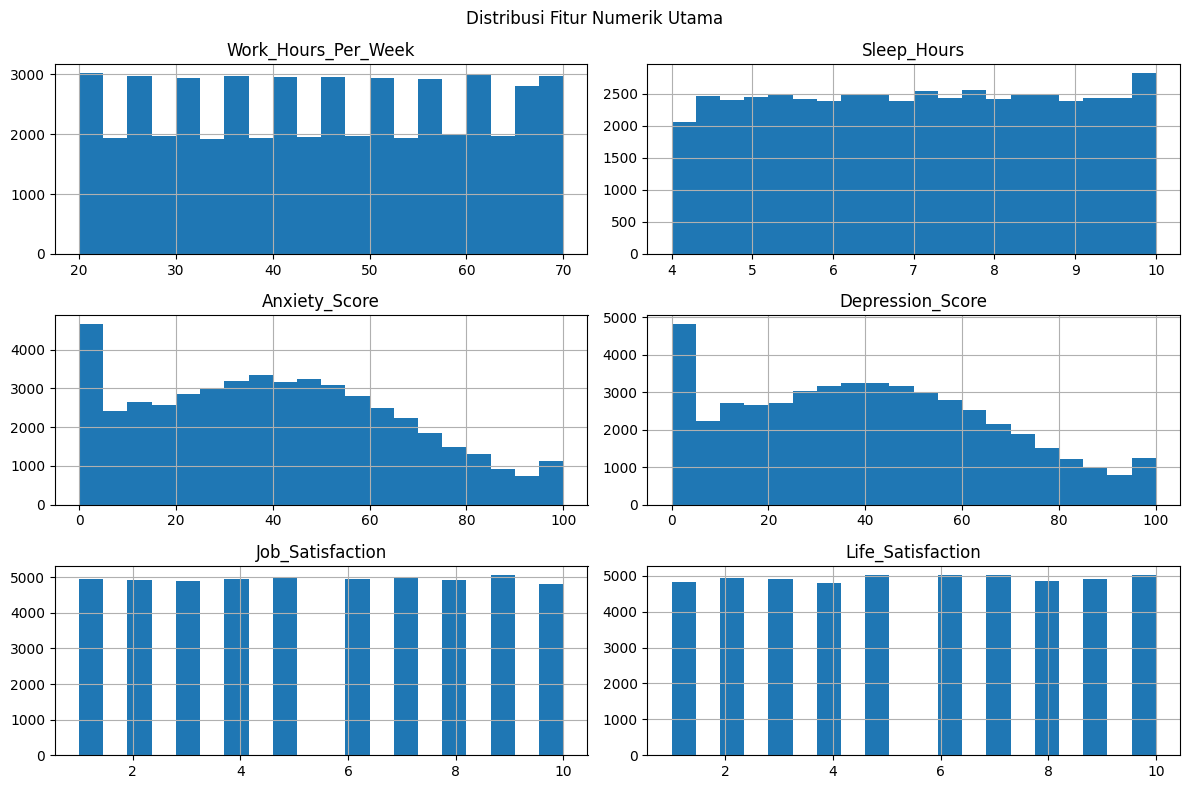

In [ ]:
selected_features = [
    'Work_Hours_Per_Week',
    'Sleep_Hours',
    'Anxiety_Score',
    'Depression_Score',
    'Job_Satisfaction',
    'Life_Satisfaction'
]

df[selected_features].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle('Distribusi Fitur Numerik Utama')
plt.tight_layout()
plt.show()

1.7 Visualisasi Deteksi Outlier

In [ ]:
numeric_columns = df.select_dtypes(include='number').columns

numeric_columns = numeric_columns.drop(
    ['person_id', 'Person_ID'],
    errors='ignore'
)

numeric_data = df[numeric_columns]

Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (numeric_data < lower_bound) |
    (numeric_data > upper_bound)
)

In [ ]:
outlier_summary = pd.DataFrame({
    'Jumlah Outlier': outlier_mask.sum(),
    'Persentase (%)': (
        outlier_mask.sum() / len(df) * 100
    ).round(2)
})

outlier_summary = outlier_summary.sort_values(
    'Jumlah Outlier',
    ascending=False
)

outlier_summary

,Jumlah Outlier,Persentase (%)
Age,0,0.0
Monthly_Income_USD,0,0.0
Work_Hours_Per_Week,0,0.0
Job_Satisfaction,0,0.0
Work_Life_Balance,0,0.0
Sleep_Hours,0,0.0
Anxiety_Score,0,0.0
Depression_Score,0,0.0
Mood_Score,0,0.0
Emotional_Stability,0,0.0


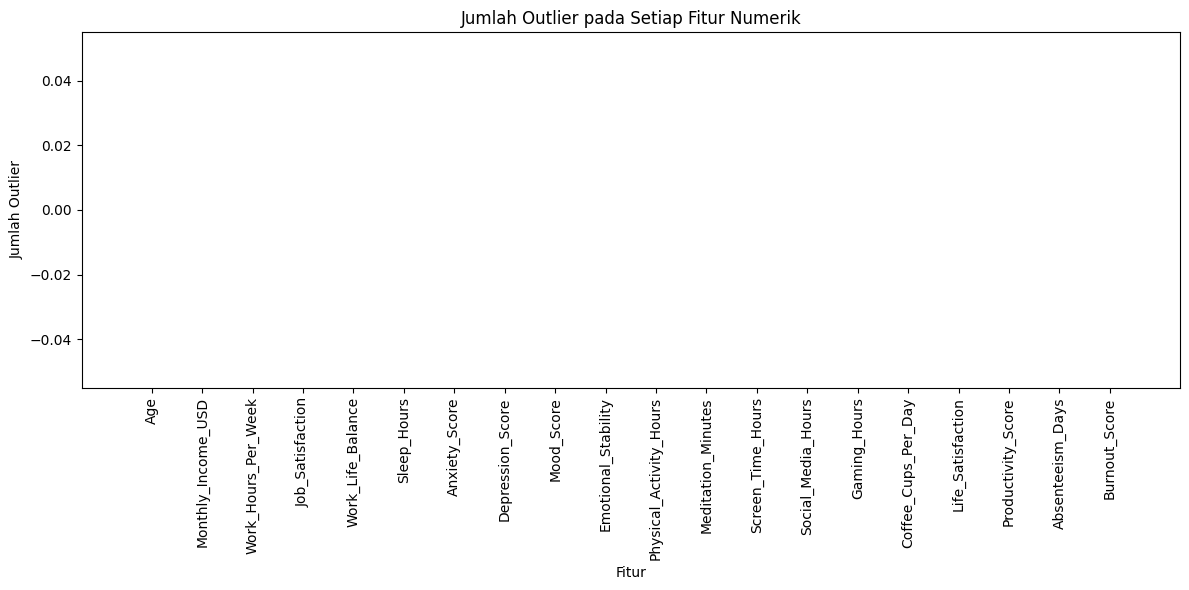

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    outlier_summary.index,
    outlier_summary['Jumlah Outlier']
)

plt.title('Jumlah Outlier pada Setiap Fitur Numerik')
plt.xlabel('Fitur')
plt.ylabel('Jumlah Outlier')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
print(outlier_summary)

                         Jumlah Outlier  Persentase (%)
Age                                   0             0.0
Monthly_Income_USD                    0             0.0
Work_Hours_Per_Week                   0             0.0
Job_Satisfaction                      0             0.0
Work_Life_Balance                     0             0.0
Sleep_Hours                           0             0.0
Anxiety_Score                         0             0.0
Depression_Score                      0             0.0
Mood_Score                            0             0.0
Emotional_Stability                   0             0.0
Physical_Activity_Hours               0             0.0
Meditation_Minutes                    0             0.0
Screen_Time_Hours                     0             0.0
Social_Media_Hours                    0             0.0
Gaming_Hours                          0             0.0
Coffee_Cups_Per_Day                   0             0.0
Life_Satisfaction                     0         

2.1 Seleksi Kolom

In [ ]:
selected_columns = list(numeric_columns) + categorical_columns

X = df[selected_columns].copy()

X.head()

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,58.0,2786.0,67,3.0,7.0,4.6,74.0,75.0,26.0,18,...,High,Weekly,Yes,Yes,No,Yes,No,Yes,Average,Critical
1,24.0,8027.0,44,5.0,8.0,4.7,58.0,80.0,29.0,37,...,Moderate,Weekly,Yes,Yes,Yes,No,Yes,No,Good,Critical
2,59.0,3177.0,60,8.0,7.0,6.3,54.0,55.0,44.0,48,...,Moderate,Daily,Yes,No,No,No,Yes,No,Average,Needs Attention
3,65.0,4093.0,25,2.0,9.0,7.1,12.0,11.0,88.0,80,...,Low,Weekly,Yes,No,No,No,No,Yes,Good,Healthy
4,64.0,NaN,52,1.0,4.0,9.1,25.0,48.0,67.0,76,...,Low,Never,Yes,No,No,No,Yes,No,Poor,Healthy


2.2 Encoding Data Kategorikal

In [ ]:
encoding_maps = {
    'Remote_Work': {
        'No': 0,
        'Hybrid': 1,
        'Yes': 2
    },

    'Sleep_Quality': {
        'Excellent': 0,
        'Good': 1,
        'Average': 2,
        'Poor': 3
    },

    'Stress_Level': {
        'Low': 0,
        'Moderate': 1,
        'High': 2
    },

    'Exercise_Frequency': {
        'Daily': 0,
        'Weekly': 1,
        'Rarely': 2,
        'Never': 3
    },

    'Alcohol_Consumption': {
        'No': 0,
        'Yes': 1
    },

    'Smoking': {
        'No': 0,
        'Yes': 1
    },

    'Healthy_Diet': {
        'No': 0,
        'Yes': 1
    },

    'Chronic_Stress': {
        'No': 0,
        'Yes': 1
    },

    'Family_History_Mental_Illness': {
        'No': 0,
        'Yes': 1
    },

    'Therapy_Attendance': {
        'No': 0,
        'Yes': 1
    },

    'Support_System': {
        'Good': 0,
        'Average': 1,
        'Poor': 2,
        'Excellent': 3
    },

    'Mental_Health_Status': {
        'Healthy': 0,
        'Needs Attention': 1,
        'Critical': 2
    }
}

for column, mapping in encoding_maps.items():
    X[column] = X[column].map(mapping)

X[categorical_columns].head()

,Remote_Work,Sleep_Quality,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1,3,2,1,1,1,0,1,0,1.0,1,2
1,1,3,1,1,1,1,1,0,1,0.0,0,2
2,0,2,1,0,1,0,0,0,1,0.0,1,1
3,2,1,0,1,1,0,0,0,0,1.0,0,0
4,0,0,0,3,1,0,0,0,1,0.0,2,0


2.3 Penanganan Missing Values

In [ ]:
print('Missing value sebelum preprocessing:')
print(X.isnull().sum())

X = X.fillna(X.median())

print(
    '\nJumlah missing value setelah preprocessing:',
    X.isnull().sum().sum()
)

Missing value sebelum preprocessing:
Age                               250
Monthly_Income_USD               1450
Work_Hours_Per_Week                 0
Job_Satisfaction                  500
Work_Life_Balance                 650
Sleep_Hours                       950
Anxiety_Score                     800
Depression_Score                  850
Mood_Score                        900
Emotional_Stability                 0
Physical_Activity_Hours          1100
Meditation_Minutes               1200
Screen_Time_Hours                 850
Social_Media_Hours                600
Gaming_Hours                      750
Coffee_Cups_Per_Day                 0
Life_Satisfaction                 700
Productivity_Score                950
Absenteeism_Days                    0
Burnout_Score                       0
Remote_Work                         0
Sleep_Quality                       0
Stress_Level                        0
Exercise_Frequency                  0
Alcohol_Consumption                 0
Smoking      

2.4 Penanganan Outlier

In [ ]:
# Karena tidak, tidak dilakukan

2.5 Standardisasi

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

X_scaled

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1.196378,-1.059170,1.497320,-0.877799,0.522638,-1.400203,1.301535,1.319769,-1.316899,-1.586087,...,1.838578,-0.455507,1.008436,1.003687,-0.996685,2.53389,-0.996765,1.016577,-0.445191,1.633584
1,-1.260836,0.543024,-0.064238,-0.176698,0.873599,-1.341801,0.681279,1.511451,-1.199485,-0.857858,...,0.411952,-0.455507,1.008436,1.003687,1.003326,-0.39465,1.003245,-0.983693,-1.341128,1.633584
2,1.268649,-0.939640,1.022063,0.874952,0.522638,-0.407356,0.526215,0.553042,-0.612419,-0.436251,...,0.411952,-1.351150,1.008436,-0.996327,-0.996685,-0.39465,1.003245,-0.983693,-0.445191,0.373764
3,1.702275,-0.659615,-1.354221,-1.228349,1.224560,0.059866,-1.101957,-1.133757,1.109642,0.790240,...,-1.014673,-0.455507,1.008436,-0.996327,-0.996685,-0.39465,-0.996765,1.016577,-1.341128,-0.886057
4,1.630004,-0.006020,0.478912,-1.578899,-0.530247,1.227922,-0.597999,0.284688,0.287749,0.636928,...,-1.014673,1.335781,1.008436,-0.996327,-0.996685,-0.39465,1.003245,-0.983693,0.450746,-0.886057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,-0.393584,-0.828669,-0.132132,0.874952,0.171676,0.001464,0.642513,0.323024,-0.573281,-0.551235,...,0.411952,-0.455507,1.008436,-0.996327,1.003326,-0.39465,1.003245,-0.983693,-0.445191,0.373764
49996,1.124107,1.338771,-1.422115,-1.228349,0.171676,-1.575412,-1.334553,-1.555457,1.305331,1.556797,...,-1.014673,-1.351150,1.008436,1.003687,-0.996685,-0.39465,-0.996765,1.016577,1.346683,-0.886057
49997,-0.538126,-0.950034,0.750488,0.874952,-1.232169,0.351880,0.952641,1.434779,-1.042934,-1.011169,...,0.411952,1.335781,1.008436,-0.996327,1.003326,-0.39465,-0.996765,1.016577,0.450746,1.633584
49998,1.413191,-0.754995,-1.082646,-0.176698,0.522638,0.001464,-0.326637,-0.903739,0.561714,0.100338,...,-1.014673,1.335781,1.008436,1.003687,-0.996685,-0.39465,-0.996765,1.016577,0.450746,-0.886057


2.6 Data Bersih

In [ ]:
print('Dimensi data setelah preprocessing:', X.shape)
print('Jumlah missing value:', X.isnull().sum().sum())

X_scaled.head()

Dimensi data setelah preprocessing: (50000, 32)
Jumlah missing value: 0


,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1.196378,-1.059170,1.497320,-0.877799,0.522638,-1.400203,1.301535,1.319769,-1.316899,-1.586087,...,1.838578,-0.455507,1.008436,1.003687,-0.996685,2.53389,-0.996765,1.016577,-0.445191,1.633584
1,-1.260836,0.543024,-0.064238,-0.176698,0.873599,-1.341801,0.681279,1.511451,-1.199485,-0.857858,...,0.411952,-0.455507,1.008436,1.003687,1.003326,-0.39465,1.003245,-0.983693,-1.341128,1.633584
2,1.268649,-0.939640,1.022063,0.874952,0.522638,-0.407356,0.526215,0.553042,-0.612419,-0.436251,...,0.411952,-1.351150,1.008436,-0.996327,-0.996685,-0.39465,1.003245,-0.983693,-0.445191,0.373764
3,1.702275,-0.659615,-1.354221,-1.228349,1.224560,0.059866,-1.101957,-1.133757,1.109642,0.790240,...,-1.014673,-0.455507,1.008436,-0.996327,-0.996685,-0.39465,-0.996765,1.016577,-1.341128,-0.886057
4,1.630004,-0.006020,0.478912,-1.578899,-0.530247,1.227922,-0.597999,0.284688,0.287749,0.636928,...,-1.014673,1.335781,1.008436,-0.996327,-0.996685,-0.39465,1.003245,-0.983693,0.450746,-0.886057


3. Modeling

3.1 Penentuan Parameter eps

k = 2, total Manhattan distance = 1238783.83
k = 3, total Manhattan distance = 1146893.32
k = 4, total Manhattan distance = 1127936.06
k = 5, total Manhattan distance = 1109839.07
k = 6, total Manhattan distance = 1105497.11
k = 7, total Manhattan distance = 1086749.49
k = 8, total Manhattan distance = 1081052.65
k = 9, total Manhattan distance = 1075847.48
k = 10, total Manhattan distance = 1071271.84


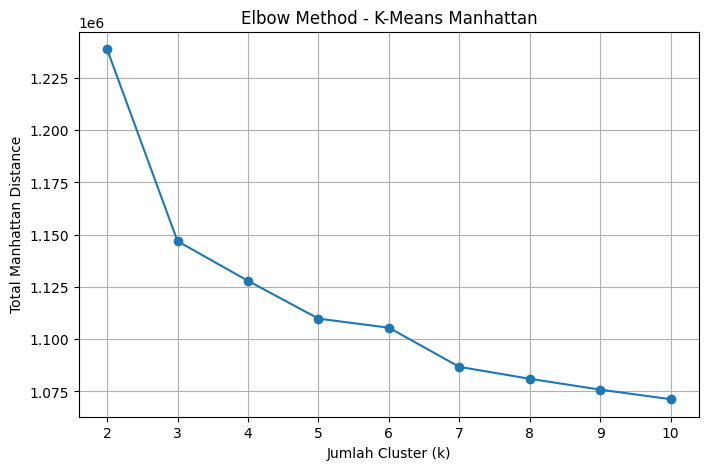

In [ ]:
def kmeans_manhattan(X, k, max_iter=100, tol=1e-4, random_state=42):
    # K-Means dengan Manhattan distance
    # Assignment cluster: jarak Manhattan
    # Update pusat cluster: mean
    rng = np.random.default_rng(random_state)
    n_samples = X.shape[0]

    initial_idx = rng.choice(n_samples, size=k, replace=False)
    centers = X[initial_idx].copy()

    for _ in range(max_iter):
        distances = cdist(X, centers, metric='cityblock')
        labels = np.argmin(distances, axis=1)

        new_centers = np.zeros_like(centers)
        for j in range(k):
            cluster_points = X[labels == j]

            if len(cluster_points) == 0:
                new_centers[j] = X[rng.integers(0, n_samples)]
            else:
                new_centers[j] = np.mean(cluster_points, axis=0)

        shift = np.abs(new_centers - centers).sum()
        centers = new_centers

        if shift < tol:
            break

    final_distances = cdist(X, centers, metric='cityblock')
    labels = np.argmin(final_distances, axis=1)
    objective = final_distances[np.arange(n_samples), labels].sum()

    return labels, centers, objective

    ks = range(2, 11)
objectives = []

for k in ks:
    labels_tmp, centers_tmp, obj = kmeans_manhattan(X_scaled.values, k, random_state=42)
    objectives.append(obj)
    print(f"k = {k}, total Manhattan distance = {obj:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(list(ks), objectives, marker='o')
plt.title('Elbow Method - K-Means Manhattan')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Total Manhattan Distance')
plt.grid(True)
plt.show()


3.2 Training K-Means Manhattan

In [ ]:
# Sesuaikan nilai k_opt berdasarkan titik elbow pada grafik
k_opt = 3

labels, centers, obj = kmeans_manhattan(X_scaled.values, k_opt, random_state=42)

print('Jumlah cluster terpilih:', k_opt)
print('Total objective final:', obj)


Jumlah cluster terpilih: 3
Total objective final: 1146893.3233506


4. Evaluasi

4.1 Jumlah Cluster

In [ ]:
df_result = df.copy()
df_result['Cluster'] = labels

print('Jumlah data per cluster:')
print(df_result['Cluster'].value_counts().sort_index())


Jumlah data per cluster:
Cluster
0    20789
1     7536
2    21675
Name: count, dtype: int64


4.2 Distribusi Cluster

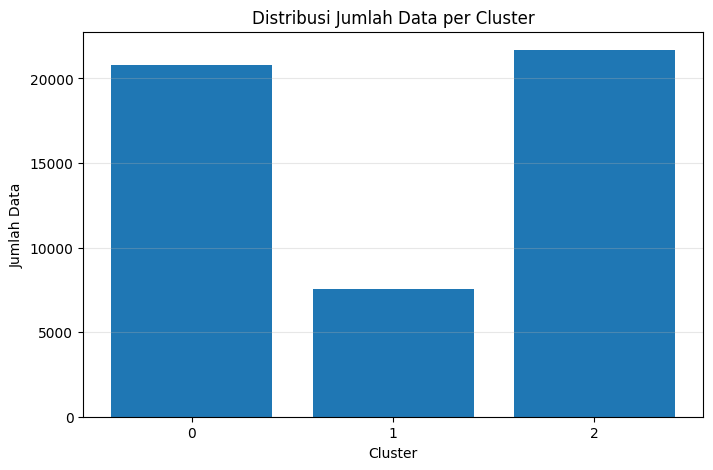

In [ ]:
cluster_counts = df_result['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.title('Distribusi Jumlah Data per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Data')
plt.grid(axis='y', alpha=0.3)
plt.show()


4.3 Silhouette Score

In [ ]:
sample_size = 5000

if X_scaled.shape[0] > sample_size:
    rng = np.random.default_rng(42)
    sample_idx = rng.choice(X_scaled.shape[0], size=sample_size, replace=False)
    sil_score = silhouette_score(X_scaled.values[sample_idx], labels[sample_idx], metric='manhattan')
else:
    sil_score = silhouette_score(X_scaled.values, labels, metric='manhattan')

print('Silhouette Score:', round(sil_score, 4))


Silhouette Score: 0.1815


4.4 Analisis Ketidakseimbangan Cluster

In [ ]:
largest_cluster = cluster_counts.idxmax()
smallest_cluster = cluster_counts.idxmin()

print(f'Cluster terbesar  : {largest_cluster} ({cluster_counts[largest_cluster]} data)')
print(f'Cluster terkecil  : {smallest_cluster} ({cluster_counts[smallest_cluster]} data)')
print(f'Selisih jumlah    : {cluster_counts.max() - cluster_counts.min()} data')


Cluster terbesar  : 2 (21675 data)
Cluster terkecil  : 1 (7536 data)
Selisih jumlah    : 14139 data


5. Reduksi Dimensi PCA

5.1 PCA

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled.values)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = labels

print('Explained variance ratio:')
print(pca.explained_variance_ratio_)
print('Total explained variance:', round(pca.explained_variance_ratio_.sum(), 4))


Explained variance ratio:
[0.26633362 0.058882  ]
Total explained variance: 0.3252


5.2 Visualisasi Hasil Klaster

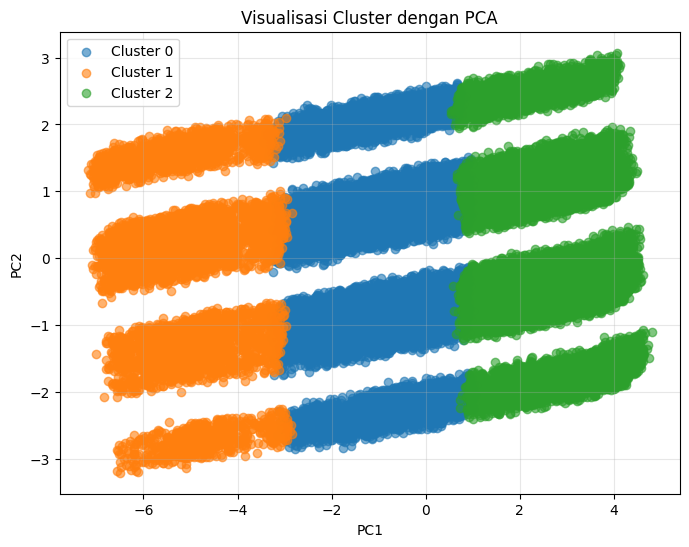

In [ ]:
plt.figure(figsize=(8, 6))

for cluster_id in sorted(df_pca['Cluster'].unique()):
    subset = df_pca[df_pca['Cluster'] == cluster_id]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster_id}', alpha=0.6)

plt.title('Visualisasi Cluster dengan PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


6. Analisis

6.1 Profil Cluster

In [ ]:
cluster_profile = df_result.groupby('Cluster')[selected_columns].mean(numeric_only=True).round(2)
display(cluster_profile)


,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,Physical_Activity_Hours,Meditation_Minutes,Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Coffee_Cups_Per_Day,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score
Cluster,,,,,,,,,,,,,,,,,,,,
0,41.43,6215.43,49.32,5.45,5.50,6.85,50.41,50.46,49.74,49.50,4.75,28.36,8.41,4.00,2.98,4.25,5.56,49.70,14.93,50.17
1,41.49,6260.11,59.52,5.55,5.54,6.31,81.41,81.29,18.76,18.68,4.10,23.10,10.10,4.03,2.98,5.13,5.47,18.84,15.02,80.96
2,41.45,6282.54,35.68,5.53,5.50,7.38,16.64,17.01,83.28,83.01,5.52,34.03,6.85,3.97,3.00,3.34,5.50,82.86,14.99,16.47


6.2 Perbandingan Cluster dengan Burnout Risk

In [ ]:
# Burnout_Risk hanya dipakai untuk interpretasi, bukan untuk training clustering
burnout_compare = pd.crosstab(df_resul  t['Cluster'], df_result['Burnout_Risk'], normalize='index') * 100
burnout_compare = burnout_compare.round(2)

display(burnout_compare)


Burnout_Risk,High,Low,Moderate
Cluster,,,
0,14.37,20.62,65.02
1,91.08,0.00,8.92
2,0.00,97.27,2.73


6.3 Visualisasi Perbandingan Antar

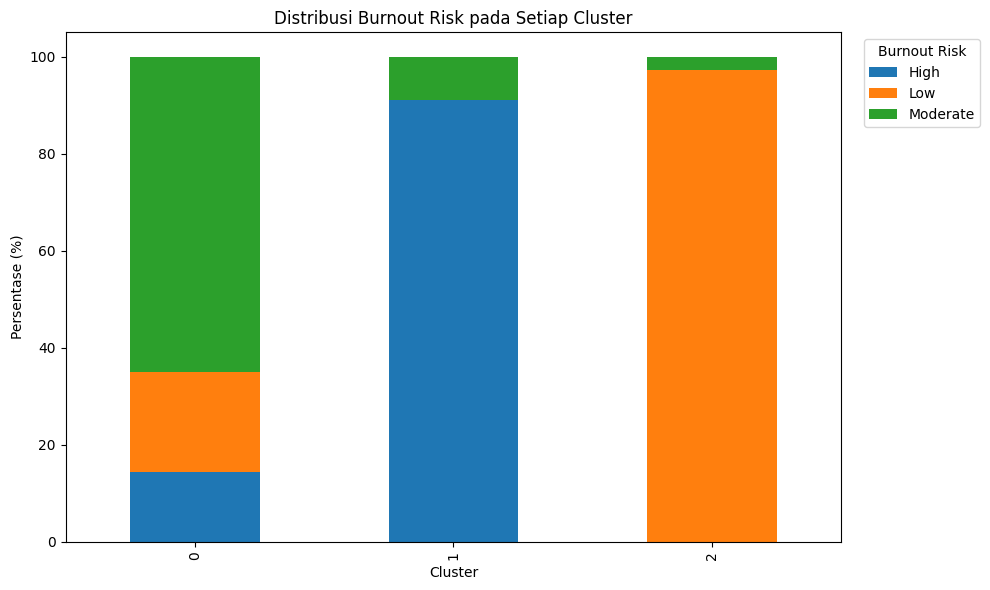

In [ ]:
burnout_compare_plot = pd.crosstab(df_result['Cluster'], df_result['Burnout_Risk'], normalize='index') * 100

ax = burnout_compare_plot.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Distribusi Burnout Risk pada Setiap Cluster')
plt.xlabel('Cluster')
plt.ylabel('Persentase (%)')
plt.legend(title='Burnout Risk', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


6.4 Ringkasan Model

In [ ]:
print('=== Ringkasan K-Means Manhattan ===')
print(f'Jumlah cluster       : {k_opt}')
print(f'Objective final      : {obj:.2f}')
print(f'Silhouette score     : {sil_score:.4f}')
print('\nInterpretasi singkat:')
print('- Cluster dibentuk berdasarkan jarak Manhattan.')
print('- Pusat cluster diperbarui menggunakan mean.')
print('- Hasil cluster dapat dibandingkan dengan Burnout_Risk untuk melihat pola risiko burnout.')


=== Ringkasan K-Means Manhattan ===
Jumlah cluster       : 3
Objective final      : 1146893.32
Silhouette score     : 0.1815

Interpretasi singkat:
- Cluster dibentuk berdasarkan jarak Manhattan.
- Pusat cluster diperbarui menggunakan mean.
- Hasil cluster dapat dibandingkan dengan Burnout_Risk untuk melihat pola risiko burnout.
